# **Bank Marketing Dataset - Logistic Regression**

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             confusion_matrix, ConfusionMatrixDisplay, 
                             roc_curve, auc, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


# **1. Load and Inspect Data**

In [3]:
data = pd.read_csv("/Users/kamillapena/Desktop/Machine Learn/bank-additional-full.csv", sep=';')  # Your file
print("Shape:", data.shape)
data.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [145]:
# Classes distribution
print(data['y'].value_counts(normalize=True))

# Data Types
print(data.dtypes)

no     0.887346
yes    0.112654
Name: y, dtype: float64
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [146]:
print("\nInfo")
data.info()


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non

In [147]:
print("\nMissing values per column:")
data.isnull().sum()


Missing values per column:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### **Consider to balance data classes**

In [148]:
# Reproducibility
STUDENT_ID = 42
np.random.seed(STUDENT_ID)

# Convert binary target 'y' from categorical 'yes'/'no' strings to numeric 1/0
data['y'] = (data['y'] == 'yes').astype(int)

# Extract all positive examples (y == 1) and make the imabalance dataset 1 in 5 positive-to-negative ratio
all_yes = data[data['y'] == 1]
sampled_no = data[data['y'] == 0].sample(n=len(all_yes)*5, random_state=STUDENT_ID)

# Combine positive and sampled negative examples, then shuffle rows randomly
data = pd.concat([all_yes, sampled_no]).sample(frac=1, random_state=STUDENT_ID).reset_index(drop=True)

print("Final data shape:", data.shape, "Yes %:", data['y'].mean())

Final data shape: (27840, 21) Yes %: 0.16666666666666666


# **2. Data Cleaning - Personal Subset & Outliers**

In [149]:
print("\nSummary statistics (numeric columns)")
data.describe()


Summary statistics (numeric columns)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000,27840.000000
mean,40.067888,275.592026,2.525647,951.023922,0.194397,-0.003825,93.560973,-40.458962,3.522393,5162.355392,0.166667
std,10.637768,279.144574,2.720803,212.939743,0.534318,1.608637,0.588624,4.748415,1.774762,75.459713,0.372685
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,106.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.327000,5099.100000,0.000000
50%,38.000000,188.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,340.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [150]:
# Remove outliers
mean_dur = data['duration'].mean()
std_dur = data['duration'].std()

# Remove rows where 'duration' exceeds mean + 2 standard deviations 
data = data[data['duration'] < (mean_dur + 2 * std_dur)].reset_index(drop=True)
print("After cleaning:", data.shape)

After cleaning: (26498, 21)


In [151]:
print("\nSummary statistics (numeric columns)")
data.describe()


Summary statistics (numeric columns)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000,26498.000000
mean,40.083365,229.844064,2.526417,951.179334,0.195675,-0.008869,93.559213,-40.443150,3.517880,5162.128032,0.140011
std,10.652220,174.790227,2.744549,212.613892,0.536561,1.610269,0.589288,4.755591,1.775995,75.475406,0.347005
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.327000,5099.100000,0.000000
50%,38.000000,178.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,308.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,833.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [152]:
print("New target % yes:")
data['y'].value_counts()

New target % yes:


0    22788
1     3710
Name: y, dtype: int64

# **3. Encode Categoricals & Prepare X/y**

In [153]:
# Encode WITHOUT NaN - fillna first!
data = data.fillna('unknown')

# Initialize LabelEncoder for ordinal transformation of categorical strings to integers
le = LabelEncoder()

# Loop over all object (categorical/string) columns and apply label encoding
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

# Extract features X: drop target 'y', keep only numeric columns (already encoded categoricals + originals)
X = data.drop('y', axis=1).select_dtypes(include=[np.number]) 
y = data['y']

In [154]:
print("X shape:", X.shape, "Sample X:\n")
X.head()

X shape: (26498, 20) Sample X:



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,51,2,2,2,0,0,2,0,6,4,89,1,999,1,0,-1.8,92.893,-46.2,1.334,5099.1
1,60,0,1,3,1,0,2,0,3,1,90,1,999,0,1,1.4,93.918,-42.7,4.960,5228.1
2,33,1,1,2,1,0,2,0,6,3,54,2,999,1,0,-1.8,92.893,-46.2,1.291,5099.1
3,35,1,1,2,0,2,0,0,6,3,74,3,999,0,1,-1.8,92.893,-46.2,1.291,5099.1
4,43,7,1,3,0,0,0,1,6,1,93,3,999,0,1,1.1,93.994,-36.4,4.857,5191.0


In [155]:
print("No NaN in X:", X.isna().sum().sum())  # 0!


No NaN in X: 0


In [156]:
print("y distribution:\n", np.bincount(y))

y distribution:
 [22788  3710]


# **4. Train-Test Split & Scale**

In [ ]:
# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler to standardize features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("TRAIN yes:", int(y_train.sum()), f"({y_train.mean():.1%})")
print("TEST yes:", int(y_test.sum()), f"({y_test.mean():.1%})")

TRAIN yes: 2983 (14.1%)
TEST yes: 727 (13.7%)


# **5. Train Logistic Regression**

In [158]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict classes
y_pred = model.predict(X_test)

# Probability of each class
y_proba = model.predict_proba(X_test)[:, 1]

In [159]:
# Top coefficients
coefs = pd.Series(
    model.coef_[0],
    index=data.drop('y', axis=1).columns).sort_values(ascending=False)

print("Top 5 features:\n", coefs.head())

Top 5 features:
 euribor3m         1.886694
duration          1.240498
cons.price.idx    0.233467
education         0.153232
poutcome          0.151278
dtype: float64


# **6. Evaluation Metrics**

In [160]:
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.3f}")
print(f"AUC-ROC: {roc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.901
AUC-ROC: 0.936

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      4573
           1       0.69      0.51      0.58       727

    accuracy                           0.90      5300
   macro avg       0.81      0.73      0.76      5300
weighted avg       0.89      0.90      0.89      5300



# **7. Confusion Matrix & ROC Curve**

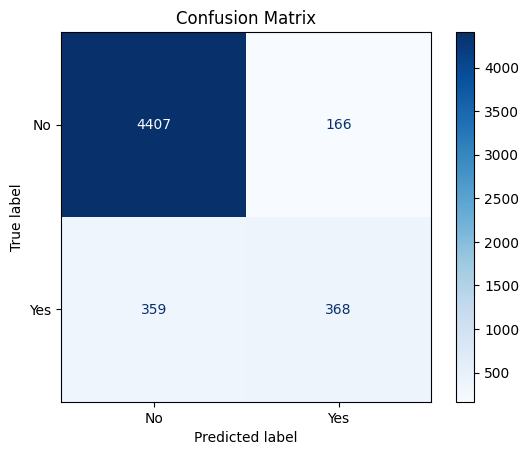

In [161]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

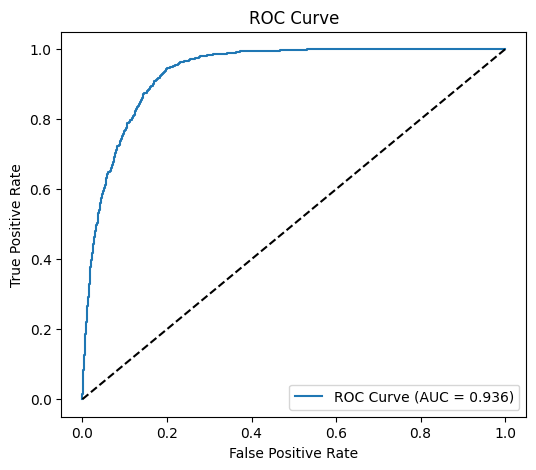

In [162]:
# ROC Curve
falsepos_rate, truepos_rate, _ = roc_curve(y_test, y_proba)
roc_auc = auc(falsepos_rate, truepos_rate)
plt.figure(figsize=(6, 5))

# Main ROC curve with dynamic AUC label in legend
plt.plot(falsepos_rate, truepos_rate, label=f'ROC Curve (AUC = {roc_auc:.3f})')

# Diagonal reference line (y=x) representing random classifier performance
plt.plot([0, 1], [0, 1], 'k--')

# Label axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [169]:
# Step 8: DataFrame y_test + NumPy y_pred (MIXED FIX)
n_samples = 20
comparison_df = pd.DataFrame({
    'Record': range(1, n_samples + 1),
    'Original_Class': y_test.iloc[:n_samples].map({0: 'No', 1: 'Yes'}),
    'Predicted_Class': ['Yes' if y_pred[i] == 1 else 'No' for i in range(n_samples)],
    'Probability_Yes': [f"{y_proba[i]:.3f}" for i in range(n_samples)],
    'Correct': ['ACUURATE' if y_test.iloc[i] == y_pred[i] else 'WRONG' for i in range(n_samples)]
})

print("**Original vs Predicted Classes (First 20 Test Records)**")
print("=" * 70)
print(comparison_df.to_string(index=False))


**Original vs Predicted Classes (First 20 Test Records)**
 Record Original_Class Predicted_Class Probability_Yes  Correct
      1             No              No           0.004 ACUURATE
      2            Yes              No           0.059    WRONG
      3             No              No           0.037 ACUURATE
      4             No              No           0.112 ACUURATE
      5             No              No           0.014 ACUURATE
      6             No              No           0.008 ACUURATE
      7             No              No           0.018 ACUURATE
      8             No              No           0.056 ACUURATE
      9            Yes             Yes           0.529 ACUURATE
     10             No              No           0.279 ACUURATE
     11             No              No           0.039 ACUURATE
     12             No              No           0.026 ACUURATE
     13             No              No           0.097 ACUURATE
     14             No              No        